# Training — Piscine Data Science (Module 3)

Notebook d'entraînement pour muscler Python (lambda, sorted, comprehensions) et les stats vues en ex00/ex01.

Règle du jeu : complète chaque `# TODO`, exécute, compare avec ce que tu attends. Pas de correction fournie ici — utilise `Test_knight.csv`/`Train_knight.csv` à la racine du projet pour vérifier tes résultats.


In [2]:
import sys
import math
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent  # ajuste selon où se trouve le notebook par rapport à la racine du projet
df_test = pd.read_csv("Test_knight.csv")
df_train = pd.read_csv("Train_knight.csv")
df_test.head()


,Sensitivity,Hability,Strength,Power,Agility,Dexterity,Awareness,Prescience,Reactivity,Midi-chlorien,...,Recovery,Evade,Stims,Sprint,Combo,Delay,Attunement,Empowered,Burst,Grasping
0,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
1,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,0.05742,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368
2,14.68,20.13,94.74,684.5,0.09867,0.07200,0.07395,0.05259,0.1586,0.05922,...,19.07,30.88,123.40,1138.0,0.1464,0.1871,0.2914,0.1609,0.3029,0.08216
3,13.54,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.04781,0.1885,0.05766,...,15.11,19.26,99.70,711.2,0.1440,0.1773,0.2390,0.1288,0.2977,0.07259
4,15.34,14.26,102.50,704.4,0.10730,0.21350,0.20770,0.09756,0.2521,0.07032,...,18.07,19.08,125.10,980.9,0.1390,0.5954,0.6305,0.2393,0.4667,0.09946


## Partie 1 — Python pur : lambda, sorted, comprehensions

Pas de pandas ici, juste des listes brutes. Objectif : muscler la lecture "de l'extérieur vers l'intérieur".


### 1.1 — Tri simple avec `key=`

Trie la liste `notes` par ordre décroissant à l'aide de `sorted` (sans lambda d'abord, avec une fonction nommée).

In [3]:
notes = [12, 5, 18, 9, 15]

# TODO: écris une fonction nommée qui retourne l'élément lui-même,
# puis utilise-la dans sorted(..., key=..., reverse=True)

def identite(x):
    return x

notes_sorted = sorted(notes, key=identite, reverse=True)
print(notes_sorted)

[18, 15, 12, 9, 5]


### 1.2 — Même tri, en lambda

Réécris le tri précédent en remplaçant ta fonction nommée par un `lambda`.

In [4]:
# TODO
notes_sorted = sorted(notes, key=lambda x:x, reverse=True)
print(notes_sorted)

[18, 15, 12, 9, 5]


### 1.3 — Trier une liste de tuples

`personnes = [("Alice", 30), ("Bob", 25), ("Chloé", 35)]`

Trie par âge croissant, puis par âge décroissant, en une ligne à chaque fois.

In [5]:
personnes = [("Alice", 30), ("Bob", 25), ("Chloé", 35)]

# TODO: tri croissant par âge
personnes_croissant = sorted(personnes, key=lambda x:x[1], reverse=False)
print(personnes_croissant)

# TODO: tri décroissant par âge
personnes_decroissant = sorted(personnes, key=lambda x:x[1], reverse=True)
print(personnes_decroissant)

[('Bob', 25), ('Alice', 30), ('Chloé', 35)]
[('Chloé', 35), ('Alice', 30), ('Bob', 25)]


### 1.4 — `sum` avec condition (generator expression)

Calcule la moyenne des notes >= 10 dans `notes`, en une seule expression `sum(... for ... if ...)`, sans construire de liste intermédiaire avec `[]`.

In [6]:
notes = [12, 5, 18, 9, 15, 3, 11]

# TODO
moyenne = sum(n for n in notes if n >= 10) / len([n for n in notes if n >= 10])
print(moyenne)

14.0


### 1.5 — Closure

Écris une fonction `main()` qui définit une variable `seuil = 10`, puis une fonction interne `au_dessus(n)` qui retourne `True` si `n > seuil` (sans passer `seuil` en paramètre — utilise la closure). Teste avec `filter(au_dessus, notes)`.

In [7]:
# TODO
def main(seuil=10):

    def au_dessus(n):
        if n > seuil:
            return True

    notes_au_dessus = filter(au_dessus, notes)
    # notes_au_dessus = filter(lambda n: n > seuil, notes) Avec une Lambda
    print(list(notes_au_dessus))

main()

[12, 18, 15, 11]


### 1.6 — Higher-order function

Écris une fonction `appliquer_a_tous(liste, func)` qui retourne une nouvelle liste où `func` a été appliquée à chaque élément (réimplémente `map` toi-même). Teste avec une lambda qui met au carré.

In [8]:
# TODO
def appliquer_a_tous(liste, func):
    resultat = []
    for n in liste:
        resultat.append(func(n))
    return resultat

notes_carres = appliquer_a_tous(notes, lambda x: x ** 2)
# notes_carres = list(map(lambda x: x ** 2, notes))

print(notes_carres)

[144, 25, 324, 81, 225, 9, 121]


---
## Partie 2 — Stats à la main (rappel ex00)

Réimplémente sans utiliser `.mean()`/`.std()`/`.var()` de pandas — juste `sum`, `len`, `math.sqrt`.

### 2.1 — Mean, variance (population), std

Sur la colonne `Sensitivity` de `df_test`.

In [9]:
col = df_test["Sensitivity"]

# TODO: mean_manual
mean_manual = sum(col) / len(col)
# TODO: variance_manual (population, /n)
variance_manual = sum(((x - mean_manual) ** 2) for x in col) / len(col)
# TODO: std_manual
std_manual = math.sqrt(variance_manual)
# Vérifie avec col.mean(), col.std(ddof=0) — pourquoi ddof=0 ici et pas la valeur par défaut ?
print(f"mean : {col.mean()} vs {mean_manual}")
print(f"std  : {col.std(ddof=0)} vs {std_manual}")

mean : 14.19625730994152 vs 14.19625730994152
std  : 3.7483639648950526 vs 3.7483639648950526


### 2.2 — Variance d'échantillon

Tire un échantillon aléatoire de taille 15 avec `.sample(n=15)`, calcule sa variance avec la correction de Bessel (`/ (n-1)`).

In [10]:
# TODO
sample = col.sample(n=15)
sample_mean = sum(col) / len(col)
sample_variance = sum(((x - sample_mean) ** 2) for x in col) / (len(col) - 1)
print(sample_variance)

14.132880839284486


### 2.3 — Densité de la loi normale

Réécris `normal_pdf(x, mean, std)` à la main (formule vue en ex00), puis trace-la par-dessus un histogramme (`stat="density"`) de `Sensitivity`.

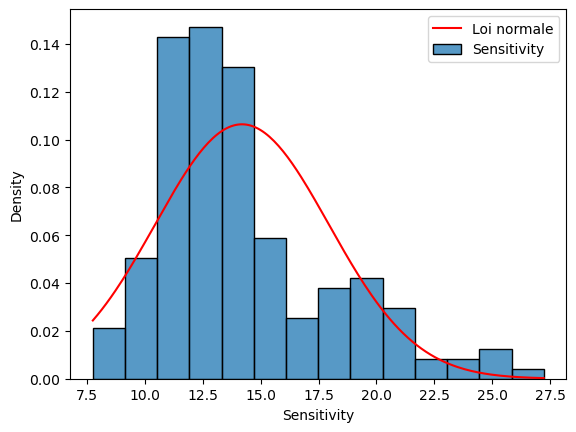

In [11]:
import numpy as np

def normal_pdf(x, mean, std):
    coefficient = 1 / (std * math.sqrt(2 * math.pi))
    exposant = -0.5 * ((x - mean) / std) ** 2
    return coefficient * math.exp(exposant)

x_points = np.linspace(col.min(), col.max(), 200)
y_points = [normal_pdf(x, mean_manual, std_manual) for x in x_points]

sns.histplot(data=col, stat="density", label="Sensitivity")
plt.plot(x_points, y_points, color="red", label="Loi normale")
plt.legend()
plt.show()

---
## Partie 3 — Corrélation (rappel ex01)

### 3.1 — Corrélation de Pearson, réimplémentée

Écris `correlation_factor(x_val, y_val)` (covariance / sqrt(somme_sq_x * somme_sq_y)). Teste sur `Strength` vs la target encodée.

In [12]:
def correlation_factor(x_val, y_val):
    # TODO
    x_mean = x_val.mean()
    y_mean = y_val.mean()
    numm = sum((x - x_mean) * (y - y_mean) for x, y in zip(x_val, y_val))
    x_std_sum = sum((x - x_mean) ** 2 for x in x_val)
    y_std_sum = sum((y - y_mean) ** 2 for y in y_val)
    return numm / math.sqrt(x_std_sum * y_std_sum)
    
y_val = (df_train["knight"] == "Jedi").astype(int)
expected_corr = df_train["Strength"].corr(y_val)
# TODO: appelle correlation_factor sur une feature de ton choix, compare avec df_train.corr()
print(f'My corr factor       :{correlation_factor(df_train["Strength"], y_val):.6f}')
print(f'Expected corr Factor :{expected_corr:.6f}')

My corr factor       :0.737403
Expected corr Factor :0.737403


### 3.2 — Toutes les features, triées (lambda + sorted)

Calcule la corrélation de chaque feature numérique avec la target, stocke dans un dict, puis affiche trié décroissant avec `sorted(..., key=lambda ..., reverse=True)` — comme dans Correlation.py.

In [13]:
# TODO
result = {}
for col in df_train.columns:
    if col == "knight":
        continue
    result[col] = correlation_factor(df_train[col], y_val)

for col, r in sorted(result.items(), key=lambda item: item[1], reverse=True):
		print(f"{col:<15}: {r:.6f}")

Empowered      : 0.793652
Prescience     : 0.790066
Stims          : 0.786797
Recovery       : 0.777633
Sprint         : 0.739672
Strength       : 0.737403
Sensitivity    : 0.721566
Power          : 0.700709
Awareness      : 0.699662
Attunement     : 0.648893
Dexterity      : 0.631987
Delay          : 0.598072
Slash          : 0.550663
Pull           : 0.537800
Lightsaber     : 0.515340
Evade          : 0.465605
Hability       : 0.446632
Burst          : 0.445847
Combo          : 0.445223
Blocking       : 0.421950
Agility        : 0.397458
Reactivity     : 0.375103
Grasping       : 0.350105
Repulse        : 0.324399
Friendship     : 0.236633
Mass           : 0.113185
Midi-chlorien  : 0.008132
Push           : -0.019446
Deflection     : -0.026489
Survival       : -0.043099


### 3.3 — Bonus : top 5 features les plus discriminantes

En une ligne, extrait les 5 noms de colonnes (pas les valeurs) les plus corrélées avec la target, triées par valeur absolue de corrélation (`abs()` dans le `key=`).

In [14]:
# TODO
top_abs = sorted(result.items(), key=lambda item: abs(float(item[1])), reverse=True)
top_cols =  (x[0] for x in top_abs) 
print(f"{list(top_cols)[:5]}")

['Empowered', 'Prescience', 'Stims', 'Recovery', 'Sprint']


---
## Partie 4 — Grille de plots (rappel structure Figure/Axes)

Réécris de mémoire (sans copier ton Histogram.py) : une grille `subplots`, `flatten()`, boucle avec `enumerate`, un histogramme par feature numérique de `df_train`, `hue="knight"`.

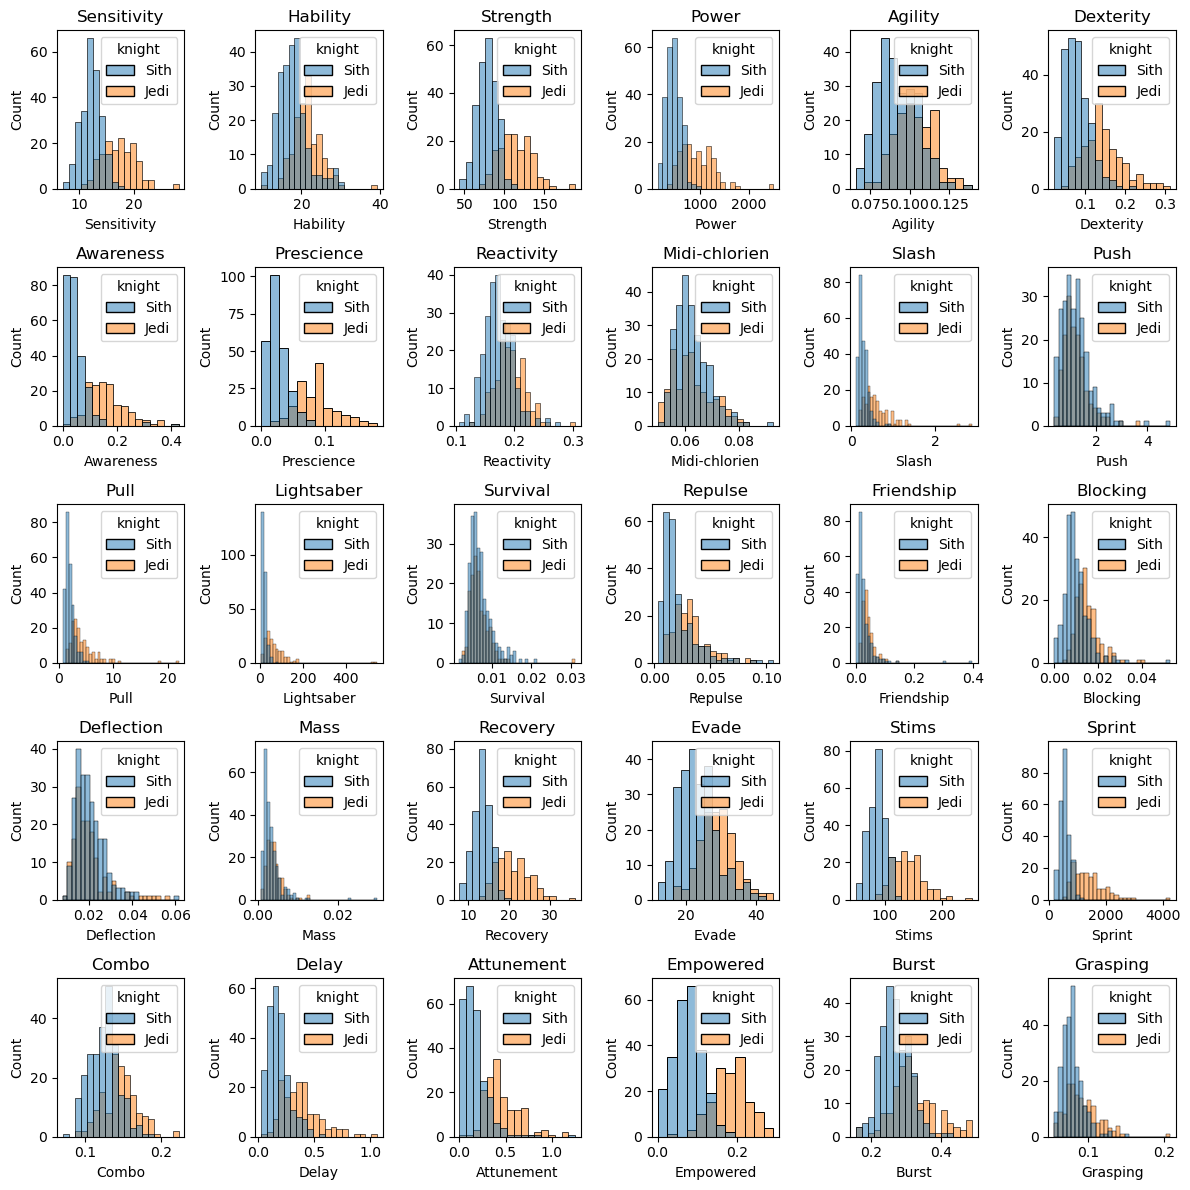

In [15]:
# TODO
fig, ax = plt.subplots(nrows=5, ncols=6, figsize=(12, 12))
ax = ax.flatten()

for i, col in enumerate(df_train.columns):
    if col == "knight":
        continue
    else:
        sns.histplot(data=df_train, x=col, hue="knight", ax=ax[i])
        ax[i].set_title(col)

plt.tight_layout()
plt.show()


---
## Partie 5 — Scatterplot & hue (rappel ex02)

Réécris de mémoire, sans copier ton `points.py`.

### 5.1 — Deux features qui séparent bien, deux qui mélangent

Calcule `correlation_factor` (celle de la Partie 3) pour toutes les features de `df_train`, prends les 2 avec la corrélation absolue la plus forte (`feat_separate`) et les 2 avec la plus faible (`feat_mix`).

In [ ]:
# TODO
# result = ... (réutilise result de la Partie 3, ou recalcule)
# feat_separate = ("", "")
# feat_mix = ("", "")


### 5.2 — Scatterplot hue pour chaque paire

Deux scatterplots (`sns.scatterplot`) côte à côte (`plt.subplots(ncols=2)`), `hue="knight"`, `palette={"Sith": "red", "Jedi": "blue"}`.

In [ ]:
# TODO


---
## Partie 6 — Standardisation / Normalisation sans casser la target (rappel ex03/ex04)

### 6.1 — `standardize_data` et `normalize_data`

Écris les deux fonctions. Chacune doit :
- ne garder que les colonnes numériques (`select_dtypes`)
- ne PAS planter sur la colonne `knight`

Vérifie que `df_train_std["Strength"].mean()` est proche de 0 et que `df_train_norm["Strength"].min()` vaut 0.

In [ ]:
# TODO
def standardize_data(x):
    pass

def normalize_data(x):
    pass


### 6.2 — Rajouter la target après coup

Standardise `df_train`, puis rajoute la colonne `knight` d'origine (non transformée) pour pouvoir faire un `hue` dessus.

In [ ]:
# TODO


---
## Partie 7 — Split stratifié (rappel ex05)

### 7.1 — `train_test_split` stratifié

Split `df_train` en `training`/`validation`, `test_size=0.2`, `stratify` sur `knight`, `random_state=42`.

In [ ]:
# TODO
from sklearn.model_selection import train_test_split


### 7.2 — Vérifier que les proportions sont préservées

Bar chart comparant `value_counts(normalize=True)` de `knight` dans `df_train`, `training`, `validation`. `plt.xticks(rotation=45, ha="right")`.

In [ ]:
# TODO


### 7.3 — Bonus : et si on avait oublié `stratify` ?

Refais un split sans `stratify`, compare le bar chart avec la version stratifiée. Est-ce que ça change beaucoup sur ce dataset ? Pourquoi (taille du dataset, déséquilibre des classes) ?

In [ ]:
# TODO
